In [ ]:
# Setup de caminho para colab e local
from pathlib import Path
from IPython.display import Image, display

IS_COLAB = False
try:
    from google.colab import drive
    IS_COLAB = True
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/100K/Tarefas/NDVI_implementation
    print('Ambiente: Google Colab')
except ModuleNotFoundError:
    print('Ambiente: local')


Ambiente: local


In [7]:
# Fallback local (Jupyter no Windows/Linux/macOS)
if not IS_COLAB:
    cwd = Path.cwd()
    candidatos = [cwd, cwd / 'NDVI_implementation', cwd.parent / 'NDVI_implementation']
    base_dir = next((p for p in candidatos if (p / 'src').exists()), None)
    if base_dir is None:
        raise FileNotFoundError('Nao encontrei a pasta src. Abra o notebook na raiz do projeto ou em NDVI_implementation.')
    %cd {base_dir}
    print(f'Ambiente local. Diretorio base: {base_dir}')


c:\Users\renan\OneDrive\Documentos\TechGuard\ProjetoSemana5\NDVI_implementation
Ambiente local. Diretorio base: c:\Users\renan\OneDrive\Documentos\TechGuard\ProjetoSemana5\NDVI_implementation


In [8]:
# Validacao rapida dos arquivos esperados
assert Path('./src').exists(), 'Pasta ./src nao encontrada'
assert Path('./src/QE_2024-09-20.tif').exists(), 'Arquivo QE_2024-09-20.tif nao encontrado em ./src'


# Calculating NDVI in Sentinel-2 multispectral products.

![headed](./src/headed.png)


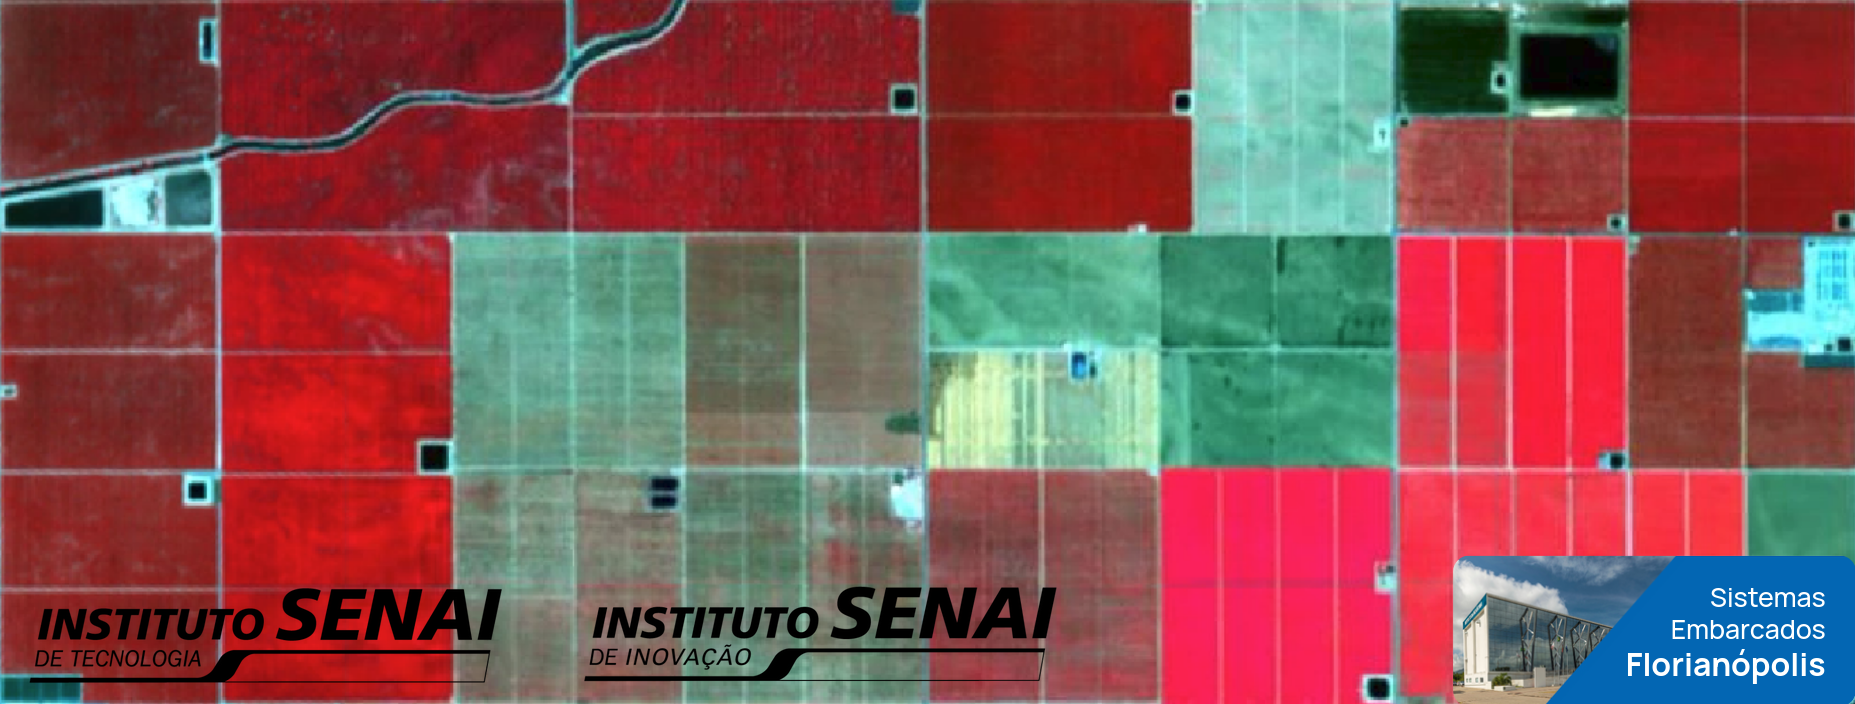

In [9]:
img_path = "./src/headed.png"
display(Image(filename=img_path))

### Loading the necessary libraries

In [10]:
import rasterio
import numpy
import os
import matplotlib.pyplot as plt
import numpy as np
import cv2

from matplotlib import colors

## Sentinel-2

Sentinel-2 is a European mission that utilizes wide-swath, high-resolution, multi-spectral imaging. Dedicated to Europeâ€™s Copernicus programme, the mission supports operational applications primarily for land services, including the monitoring of vegetation, soil and water cover, as well as the observation of inland waterways and coastal

"A summary of the spectral bands sensed by the Sentinel mission is presented below."
![S2Bands](./src/senteinel_2_bands.jpg)


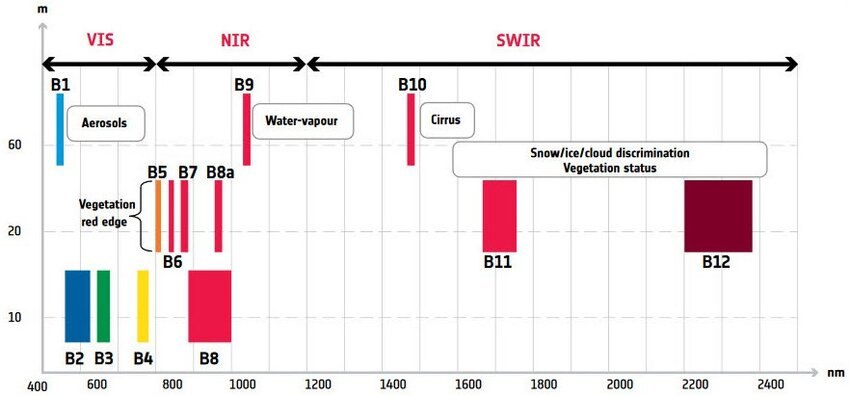

In [11]:
img_path = "./src/sentinel_2_bands.jpg"
display(Image(filename=img_path))

## Below, we present how a multispectral product can be read and processed using Python as base.
###  1. Extracting the data from the red and near-infrared bands.


In [12]:
%cd ./src

current_dir = os.getcwd()

for filename in os.listdir("."):
    if filename.endswith(".tif") and os.path.isfile(filename):
        filedir = f'{current_dir}/{filename}'

c:\Users\renan\OneDrive\Documentos\TechGuard\ProjetoSemana5\NDVI_implementation\src


In [13]:
with rasterio.open(filedir) as raster:
    raster_arr = raster.read()


B4 = raster_arr[3] #band_red
B8 = raster_arr[7] #band_nir


###  2. Calculating NDVI

The Normalized Difference Vegetation Index (NDVI) is a fundamental metric used to assess crop and vegetation health based on satellite imagery. It evaluates plant conditions by measuring how much light at different wavelengths is absorbed and reflected, eliminating the need for frequent field visits.

NDVI is typically derived from satellite measurements of surface reflectance using the following formula:

NDVI = (NIR â€“ RED) / (NIR + RED)

In [14]:
# Do not display error when divided by zero

numpy.seterr(divide='ignore', invalid='ignore')

# NDVI
ndvi = (B8.astype(float) - B4.astype(float)) / (B8 + B4)



### Checking the range of NDVI values(excluding NaN)
Let's print the minimum and maximum values in our calculated ndvi. Because we're using the NDVI formula to normalize the input bands, we know that our expected values should fall within -1.0 to +1.0.

In [15]:
print(numpy.nanmin(ndvi))
print(numpy.nanmax(ndvi))

-1.0
1.0


### Applying a color scheme to visualize the NDVI values on the new image
The values in our NDVI will range from -1 to 1. To best visualize this, we want to use a diverging color scheme, and we want to center the colorbar at a defined midpoint.



In [16]:
class MidpointNormalize(colors.Normalize):

    def __init__(self, vmin=None, vmax=None, midpoint=None, clip=False):
        self.midpoint = midpoint
        colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):

        x, y = [self.vmin, self.midpoint, self.vmax], [0, 0.5, 1]
        return numpy.ma.masked_array(numpy.interp(value, x, y), numpy.isnan(value))

### Interpretation of NDVI

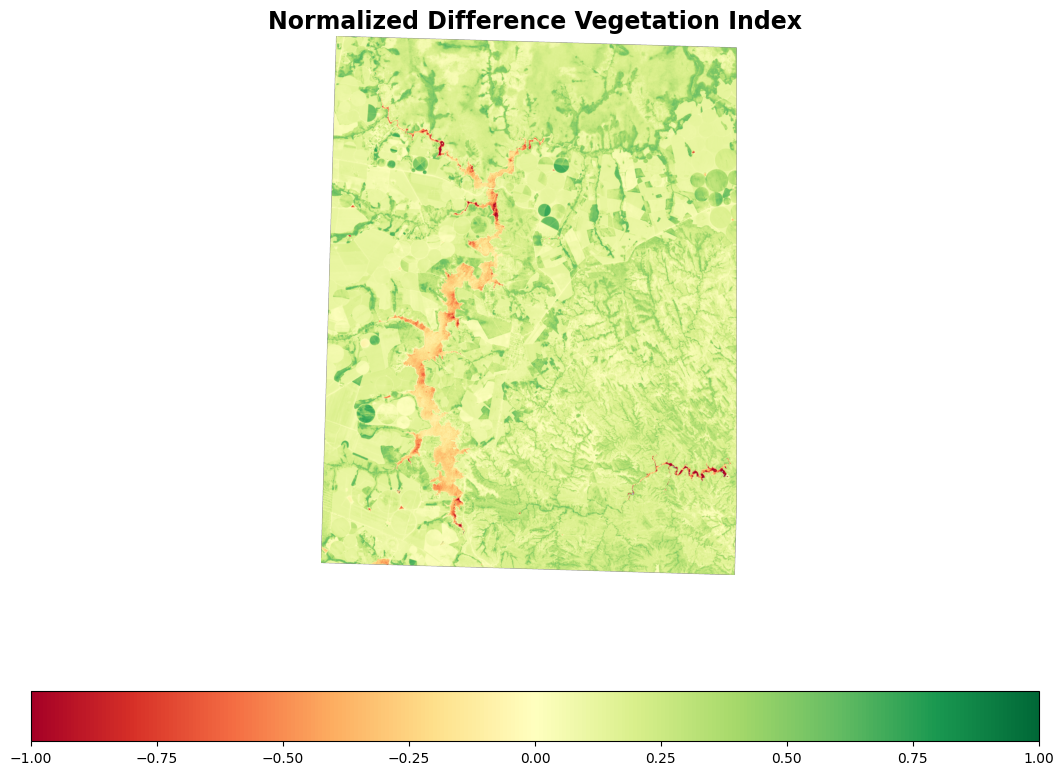

In [17]:

# Set min/max values from NDVI range for image

min=numpy.nanmin(ndvi)
max=numpy.nanmax(ndvi)

# Set our custom midpoint for most effective NDVI analysis
mid=0.1

# Setting color scheme ref:https://matplotlib.org/users/colormaps.html as a reference
colormap = plt.cm.RdYlGn
norm = MidpointNormalize(vmin=min, vmax=max, midpoint=mid)
fig = plt.figure(figsize=(20,10))


ax = fig.add_subplot(111)

# Use 'imshow' to specify the input data, colormap, min, max, and norm for the colorbar
cbar_plot = ax.imshow(ndvi, cmap=colormap, vmin=min, vmax=max)


# Turn off the display of axis labels
ax.axis('off')

# Set a title
ax.set_title('Normalized Difference Vegetation Index', fontsize=17, fontweight='bold')

# Configure the colorbar
cbar = fig.colorbar(cbar_plot, orientation='horizontal', shrink=0.65)

# let's visualize
plt.show()

## Generating a histogram of NDVI values

A Histogram or any other chart  can be useful for quick analysis by giving a visual insight into the distribution of "healthy" vs "unhealthy" vegetation values in your study area.

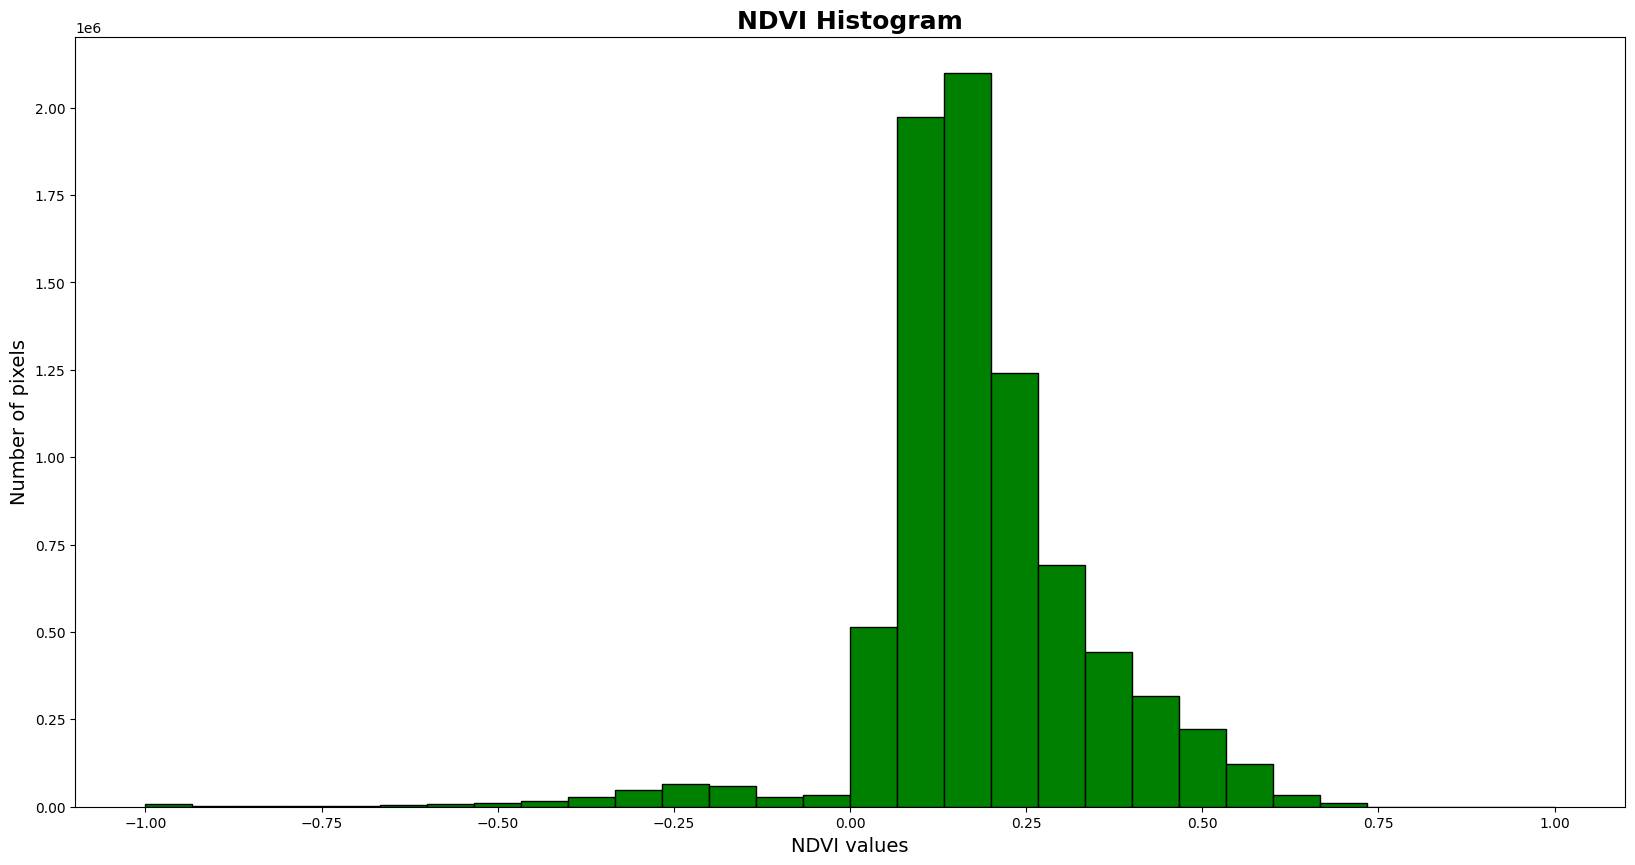

In [18]:
# Define a new figure
fig2 = plt.figure(figsize=(20,10))

# Give this new figure a subplot, which will contain the histogram itself
ax = fig2.add_subplot(111)

# Add a title & (x,y) labels to the plot
plt.title("NDVI Histogram", fontsize=18, fontweight='bold')
plt.xlabel("NDVI values", fontsize=14)
plt.ylabel("Number of pixels", fontsize=14)


# For the x-axis, we want to count every pixel that is not an empty value
x = ndvi[~numpy.isnan(ndvi)]
color = 'g'
# call 'hist` with our x-axis, bins, and color details
ax.hist(x,bins=30,color=color,histtype='bar', ec='black')

plt.show()

### Image Categorization

In [19]:
ndvi_class_bin  = [-1, -0.5, 0, 0.25, 0.5, 1]
ndvi_classified = np.digitize(ndvi, ndvi_class_bin)
print(np.unique(ndvi_classified))

[1 2 3 4 5 6]


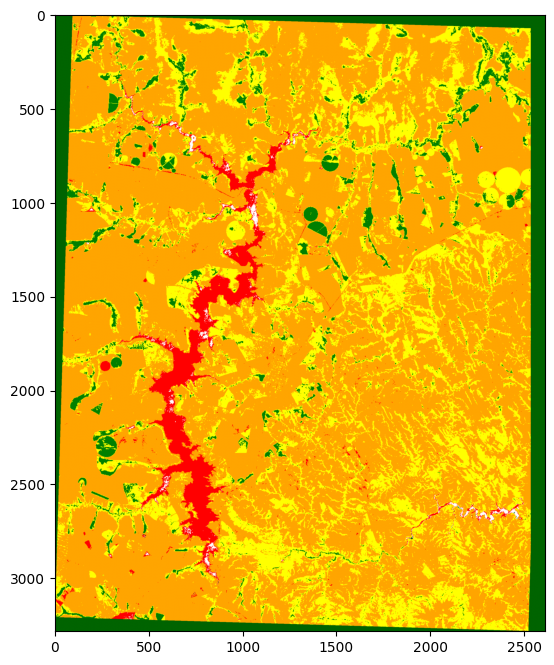

In [20]:
cmap = colors.ListedColormap(['white', 'red', 'orange', 'yellow', 'green', 'darkgreen'])

plt.figure(figsize=[14,8])
plt.imshow(ndvi_classified, cmap=cmap, vmin=1, vmax=6)

### Filter â€“ used to reduce noise and produce more homogeneous regions.

In [21]:
ndvi_classified = ndvi_classified.astype(np.uint8)


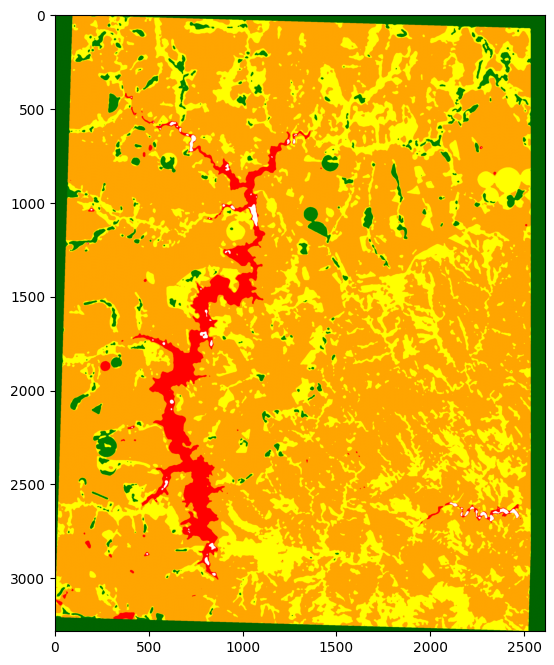

In [22]:
median = cv2.medianBlur(ndvi_classified, 13)
plt.figure(figsize=[14,8])
plt.imshow(median, cmap=cmap, vmin=1, vmax=6)

### Save files.

In [23]:
# # Call 'savefig' to save this plot to an image file
# fig.savefig("ndvi-image.png", dpi=200, bbox_inches='tight', pad_inches=0.7)

# # Save the generated figure to an external image file
# fig2.savefig("ndvi-histogram.png", dpi=200, bbox_inches='tight', pad_inches=0.5)

# save NDVI raster.
